# Checkpoint 1 
## (Do not remove any comments that start with"# @@@".) 

Reminder: 

- You are being evaluated for completion and effort in this checkpoint. 
- Avoid manual labor / hard coding as much as possible, everything we've taught you so far are meant to simplify and automate your process.
- Please do not remove any comment that starts with: "# @@@". 

We will be working with the same `states_edu.csv` that you should already be familiar with from the tutorial.

We investigated Grade 8 reading score in the tutorial. For this checkpoint, you are asked to investigate another test. Here's an overview:

* Choose a specific response variable to focus on
>Grade 4 Math, Grade 4 Reading, Grade 8 Math
* Pick or create features to use
>Will all the features be useful in predicting test score? Are some more important than others? Should you standardize, bin, or scale the data?
* Explore the data as it relates to that test
>Create at least 2 visualizations (graphs), each with a caption describing the graph and what it tells us about the data
* Create training and testing data
>Do you want to train on all the data? Only data from the last 10 years? Only Michigan data?
* Train a ML model to predict outcome 
>Define what you want to predict, and pick a model in sklearn to use (see sklearn <a href="https://scikit-learn.org/stable/modules/linear_model.html">regressors</a>).


Include comments throughout your code! Every cleanup and preprocessing task should be documented.


<h2> Data Cleanup </h2>

Import `numpy`, `pandas`, and `matplotlib`.

(Feel free to import other libraries!)

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import statsmodels.api as sm
import sklearn.model_selection as ms
from sklearn.model_selection import train_test_split


Load in the "states_edu.csv" dataset and take a look at the head of the data

In [51]:
df = pd.read_csv('../data/states_edu.csv')
df.head()

,PRIMARY_KEY,STATE,YEAR,ENROLL,TOTAL_REVENUE,FEDERAL_REVENUE,STATE_REVENUE,LOCAL_REVENUE,TOTAL_EXPENDITURE,INSTRUCTION_EXPENDITURE,...,GRADES_4_G,GRADES_8_G,GRADES_12_G,GRADES_1_8_G,GRADES_9_12_G,GRADES_ALL_G,AVG_MATH_4_SCORE,AVG_MATH_8_SCORE,AVG_READING_4_SCORE,AVG_READING_8_SCORE
0,1992_ALABAMA,ALABAMA,1992,NaN,2678885.0,304177.0,1659028.0,715680.0,2653798.0,1481703.0,...,57948.0,58025.0,41167.0,NaN,NaN,731634.0,208.0,252.0,207.0,NaN
1,1992_ALASKA,ALASKA,1992,NaN,1049591.0,106780.0,720711.0,222100.0,972488.0,498362.0,...,9748.0,8789.0,6714.0,NaN,NaN,122487.0,NaN,NaN,NaN,NaN
2,1992_ARIZONA,ARIZONA,1992,NaN,3258079.0,297888.0,1369815.0,1590376.0,3401580.0,1435908.0,...,55433.0,49081.0,37410.0,NaN,NaN,673477.0,215.0,265.0,209.0,NaN
3,1992_ARKANSAS,ARKANSAS,1992,NaN,1711959.0,178571.0,958785.0,574603.0,1743022.0,964323.0,...,34632.0,36011.0,27651.0,NaN,NaN,441490.0,210.0,256.0,211.0,NaN
4,1992_CALIFORNIA,CALIFORNIA,1992,NaN,26260025.0,2072470.0,16546514.0,7641041.0,27138832.0,14358922.0,...,418418.0,363296.0,270675.0,NaN,NaN,5254844.0,208.0,261.0,202.0,NaN


You should always familiarize yourself with what each column in the dataframe represents. Read about the states_edu dataset here: https://www.kaggle.com/noriuk/us-education-datasets-unification-project

Use this space to rename columns, deal with missing data, etc. _(optional)_

In [52]:
df.rename({
    'GRADES_PK_G':'ENROLL_PREK',
    'GRADES_KG_G':'ENROLL_KINDER',
    'GRADES_4_G':'ENROLL_4',
    'GRADES_8_G':'ENROLL_8',
    'GRADES_12_G':'ENROLL_12',
    'GRADES_1_8_G':'ENROLL_PRIMARY',
    'GRADES_9_12_G':'ENROLL_HS',
    'GRADES_ALL_G':'ENROLL_ALL',
    'ENROLL':'ENROLL_ALL_EST'
    },
    axis=1, inplace=True)


df_nontrivial=df.dropna()
df_nontrivial.head()

,PRIMARY_KEY,STATE,YEAR,ENROLL_ALL_EST,TOTAL_REVENUE,FEDERAL_REVENUE,STATE_REVENUE,LOCAL_REVENUE,TOTAL_EXPENDITURE,INSTRUCTION_EXPENDITURE,...,ENROLL_4,ENROLL_8,ENROLL_12,ENROLL_PRIMARY,ENROLL_HS,ENROLL_ALL,AVG_MATH_4_SCORE,AVG_MATH_8_SCORE,AVG_READING_4_SCORE,AVG_READING_8_SCORE
561,2003_ALABAMA,ALABAMA,2003,727900.0,5196054.0,567704.0,2966981.0,1661369.0,5298932.0,2817111.0,...,57323.0,59663.0,42005.0,466920.0,205907.0,731220.0,223.0,262.0,207.0,253.0
562,2003_ALASKA,ALASKA,2003,133303.0,1425948.0,259423.0,813371.0,353154.0,1610289.0,763525.0,...,10115.0,11140.0,8651.0,82337.0,40238.0,133933.0,233.0,279.0,212.0,256.0
563,2003_ARIZONA,ARIZONA,2003,875111.0,6529894.0,740579.0,2912629.0,2876686.0,6210287.0,2810907.0,...,76207.0,76376.0,68815.0,613442.0,307272.0,1012068.0,229.0,271.0,209.0,255.0
564,2003_ARKANSAS,ARKANSAS,2003,450158.0,3241275.0,379947.0,2394336.0,466992.0,3242799.0,1768713.0,...,34070.0,37004.0,28840.0,281834.0,132712.0,454523.0,229.0,266.0,214.0,258.0
565,2003_CALIFORNIA,CALIFORNIA,2003,6226552.0,59815855.0,5795655.0,33617766.0,20402434.0,59749885.0,29561563.0,...,493415.0,500143.0,395194.0,3929869.0,1854518.0,6413867.0,227.0,267.0,206.0,251.0


<h2>Exploratory Data Analysis (EDA) </h2>

Chosen one of Grade 4 Reading, Grade 4 Math, or Grade 8 Math to focus on: *Grade 8 Math*

How many years of data are logged in our dataset? 

In [53]:
# @@@ 1
uniqueYears = df['YEAR'].unique()
print(uniqueYears)

uniqueNoNANYears = df_nontrivial['YEAR'].unique()
print(uniqueNoNANYears)


[1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005
 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 1986 1987 1988
 1989 1990 1991 2017 2019]
[2003 2005 2007 2009 2011 2013 2015]


Let's compare Michigan to Ohio. Which state has the higher average across all years in the test you chose?

In [54]:
# @@@ 2

df_ohio = df[(df['STATE'] == 'OHIO') & (df['AVG_MATH_8_SCORE'].notna())]
df_michigan = df[(df['STATE'] == 'MICHIGAN') & (df['AVG_MATH_8_SCORE'].notna())]

ohio_avg = df_ohio['AVG_MATH_8_SCORE'].mean()
michigan_avg = df_michigan['AVG_MATH_8_SCORE'].mean()

print("Ohio average Grade 8 Math score:", ohio_avg)
print("Michigan average Grade 8 Math score:", michigan_avg)


Ohio average Grade 8 Math score: 282.25
Michigan average Grade 8 Math score: 276.1666666666667


Find the average for your chosen test across all states in 2019

In [55]:
# @@@ 3
df_2019 = df[df['YEAR'] == 2019]
df_2019.set_index('STATE', inplace=True)

# Remove non-states
df_2019.drop('DODEA', axis=0, inplace=True)
df_2019.drop('NATIONAL', axis=0, inplace=True)
df_2019.drop('DISTRICT_OF_COLUMBIA', axis=0, inplace=True)


df_2019.head()

df_2019.shape
df_2019.head(53)

df_2019['AVG_MATH_8_SCORE'].mean()

np.float64(281.28)

For each state, find a maximum value for your chosen test score

In [56]:
# @@@ 4
# Total historically
df_maxGrade4Statewide = df[df['AVG_MATH_8_SCORE'] == df['AVG_MATH_8_SCORE'].max()]
df_maxGrade4Statewide

,PRIMARY_KEY,STATE,YEAR,ENROLL_ALL_EST,TOTAL_REVENUE,FEDERAL_REVENUE,STATE_REVENUE,LOCAL_REVENUE,TOTAL_EXPENDITURE,INSTRUCTION_EXPENDITURE,...,ENROLL_4,ENROLL_8,ENROLL_12,ENROLL_PRIMARY,ENROLL_HS,ENROLL_ALL,AVG_MATH_4_SCORE,AVG_MATH_8_SCORE,AVG_READING_4_SCORE,AVG_READING_8_SCORE
1092,2013_MASSACHUSETTS,MASSACHUSETTS,2013,920968.0,16114783.0,818054.0,6428534.0,8868195.0,16201905.0,9097982.0,...,70862.0,72116.0,67429.0,569089.0,287478.0,955739.0,253.0,301.0,232.0,277.0


In [57]:
# @@@ 4

#Total in 2019
df_maxGrade4Statewide_2019 = df_2019[df_2019['AVG_MATH_8_SCORE'] == df_2019['AVG_MATH_8_SCORE'].max()]
df_maxGrade4Statewide_2019

,PRIMARY_KEY,YEAR,ENROLL_ALL_EST,TOTAL_REVENUE,FEDERAL_REVENUE,STATE_REVENUE,LOCAL_REVENUE,TOTAL_EXPENDITURE,INSTRUCTION_EXPENDITURE,SUPPORT_SERVICES_EXPENDITURE,...,ENROLL_4,ENROLL_8,ENROLL_12,ENROLL_PRIMARY,ENROLL_HS,ENROLL_ALL,AVG_MATH_4_SCORE,AVG_MATH_8_SCORE,AVG_READING_4_SCORE,AVG_READING_8_SCORE
STATE,,,,,,,,,,,,,,,,,,,,,
MASSACHUSETTS,2019_MASSACHUSETTS,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,247.0,294.0,231.0,273.0


*Refer to the `Grouping and Aggregating` section in Tutorial 0 if you are stuck.

<h2> Feature Engineering </h2>

After exploring the data, you can choose to modify features that you would use to predict the performance of the students on your chosen response variable. 

You can also create your own features. For example, perhaps you figured that maybe a state's expenditure per student may affect their overall academic performance so you create a expenditure_per_student feature.

Use this space to modify or create features.

In [58]:
# @@@ 5
# Sort observations chronologically per state
df = df.sort_values(['STATE', 'YEAR']).copy()

# Feature 1
# Average Grade 8 Math score from prior cohort. 
# Idea: While different cohorts may have different 8th grade math performance, we also want to consider that some factors stay, such as curriculum, teachers, environment etc.
# So maybe one way to see if this could reliably predict the 8th grade math score of the next cohort is to use the prior cohort's last available 8th grade math score. 
df['PRIOR_MATH_8_SCORE'] = (
    df.groupby('STATE')['AVG_MATH_8_SCORE']
      .transform(lambda scores: scores.shift(1).ffill())
)

# Feature 2: Grade 4 math score from exactly four years earlier
# Idea: Well you have the same cohort, but this tells you if the same cohort when they were younger had some innate ability. 
math4_four_years_ago = df[
    ['STATE', 'YEAR', 'AVG_MATH_4_SCORE']
].copy()
math4_four_years_ago['YEAR'] += 4

math4_four_years_ago.rename(
    columns={'AVG_MATH_4_SCORE': 'MATH_4_SCORE_4_YEARS_AGO'},
    inplace=True
)

df = df.merge(
    math4_four_years_ago,
    on=['STATE', 'YEAR'],
    how='left'
)

# df with relevant + new features
df[
    [
        'STATE',
        'YEAR',
        'AVG_MATH_8_SCORE',
        'PRIOR_MATH_8_SCORE',
        'MATH_4_SCORE_4_YEARS_AGO'
    ]
].dropna().head(10)

,STATE,YEAR,AVG_MATH_8_SCORE,PRIOR_MATH_8_SCORE,MATH_4_SCORE_4_YEARS_AGO
21,ALABAMA,2007,266.0,262.0,223.0
23,ALABAMA,2009,269.0,266.0,225.0
25,ALABAMA,2011,269.0,269.0,229.0
27,ALABAMA,2013,269.0,269.0,228.0
29,ALABAMA,2015,267.0,269.0,231.0
31,ALABAMA,2017,268.0,267.0,233.0
32,ALABAMA,2019,269.0,268.0,231.0
54,ALASKA,2007,283.0,279.0,233.0
56,ALASKA,2009,283.0,283.0,236.0
58,ALASKA,2011,283.0,283.0,237.0


Feature engineering justification: **<BRIEFLY DESCRIBE WHY YOU MADE THE CHANGES THAT YOU DID\>**

So rather than measuring the effect of education funding per student on 8th grade math performance, we'd rather look at the performance of 8th grade scores over time in each state, and to check for the 4th grade math score of the SAME cohort.

Feature 1: Prior cohort 8th grade math score.
I wanted to use this as a feature as a school environment, typically (but not always) don't have enough time to change factors such as classroom environment, curricula, instructor rosters, Educational KPIs etc. We want to figure if using simply the past 8th grade cohort presents some kind of persistence with regards to the current cohorts performance.

Feature 2: The same cohort, 4 years ago, and their average math performance
Now this feature was again also time based, and supposedly an improvement for the one we did in our tutorial. In our tutorial, we visualized average grade 4 math score vs grade 8, which is sensible, but this grade 4 cohort is not the same as the current grade 8 cohort. These groups are separate, and this is not going to be a good measure of suppose, aggregate cohort ability, which varies per cohort. This way, we can see if students in grade 4 who struggled/excelled in math, will do the same after 4 years.

<h2>Visualization</h2>

Investigate the relationship between your chosen response variable and at least two predictors using visualizations. Write down your observations.

**Visualization 1**

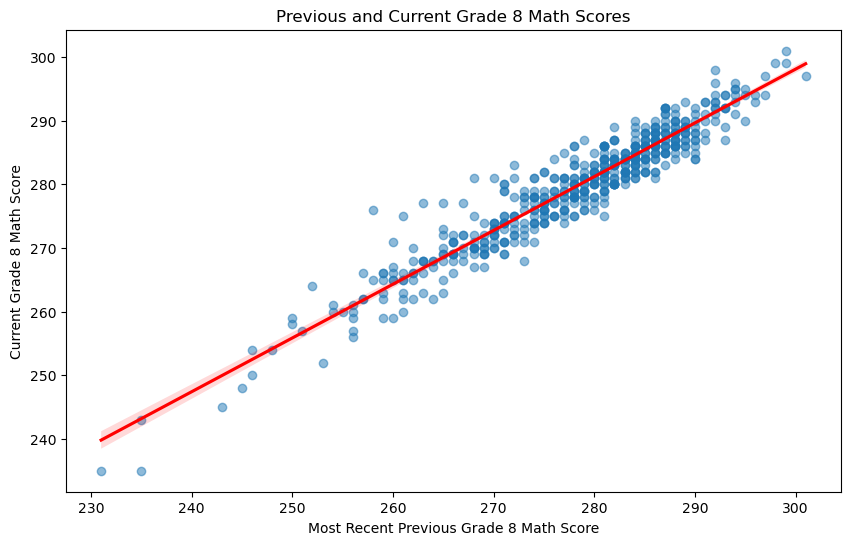

In [59]:
# @@@ 6
plot1_data = df[
    ['PRIOR_MATH_8_SCORE', 'AVG_MATH_8_SCORE']
].dropna()

plt.figure(figsize=(10, 6))

sns.regplot(
    data=plot1_data,
    x='PRIOR_MATH_8_SCORE',
    y='AVG_MATH_8_SCORE',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)

plt.title('Previous and Current Grade 8 Math Scores')
plt.xlabel('Most Recent Previous Grade 8 Math Score')
plt.ylabel('Current Grade 8 Math Score')
plt.show()

**<CAPTION FOR VIZ 1>**

**Visualization 2**

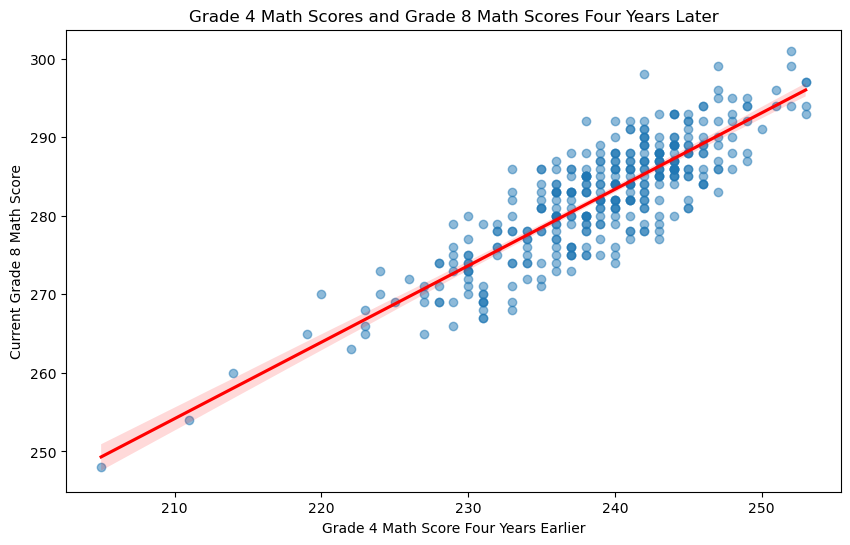

In [60]:
# @@@ 7
plot2_data = df[
    ['MATH_4_SCORE_4_YEARS_AGO', 'AVG_MATH_8_SCORE']
].dropna()

plt.figure(figsize=(10, 6))

sns.regplot(
    data=plot2_data,
    x='MATH_4_SCORE_4_YEARS_AGO',
    y='AVG_MATH_8_SCORE',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)

plt.title('Grade 4 Math Scores and Grade 8 Math Scores Four Years Later')
plt.xlabel('Grade 4 Math Score Four Years Earlier')
plt.ylabel('Current Grade 8 Math Score')
plt.show()

**<CAPTION FOR VIZ 2>**

<h2> Data Creation </h2>

_Use this space to create train/test data_

In [61]:
from sklearn.model_selection import train_test_split

In [62]:
# @@@ 8

feature_columns = [
    'PRIOR_MATH_8_SCORE',
    'MATH_4_SCORE_4_YEARS_AGO'
]

response_column = 'AVG_MATH_8_SCORE'

model_columns = [
    'YEAR',
    'PRIOR_MATH_8_SCORE',
    'MATH_4_SCORE_4_YEARS_AGO',
    'AVG_MATH_8_SCORE'
]

df_model = df[model_columns].dropna()

In [63]:
# @@@ 9 

# Split chronologically to avoid training on future years when evaluating past years.
train = df_model[df_model['YEAR'] < 2017]
test = df_model[df_model['YEAR'] >= 2017]

X_train = train[feature_columns]
y_train = train[response_column]

X_test = test[feature_columns]
y_test = test[response_column]

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))
print("Training years:", train['YEAR'].min(), "to", train['YEAR'].max())
print("Testing years:", test['YEAR'].min(), "to", test['YEAR'].max())

Training observations: 267
Testing observations: 106
Training years: 1996 to 2015
Testing years: 2017 to 2019


<h2> Prediction </h2>

ML Models [Resource](https://medium.com/@vijaya.beeravalli/comparison-of-machine-learning-classification-models-for-credit-card-default-data-c3cf805c9a5a)

In [73]:
# @@@ 10
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge


In [65]:
# @@@ 11
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)



In [66]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [67]:
y_pred = model.predict(X_test)

## Evaluation

Choose some metrics to evaluate the performance of your model, some of them are mentioned in the tutorial.

In [68]:
# @@@ 12
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

Mean Squared Error: 4.105307429208882
R^2 Score: 0.9053320671712827


We have copied over the graphs that visualize the model's performance on the training and testing set. 

Change `col_name` and modify the call to `plt.ylabel()` to isolate how a single predictor affects the model.

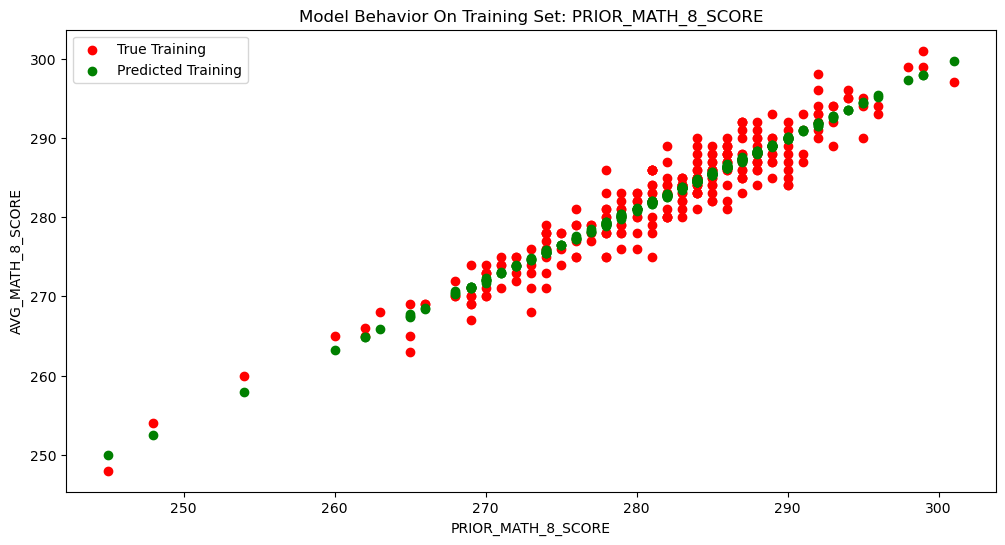

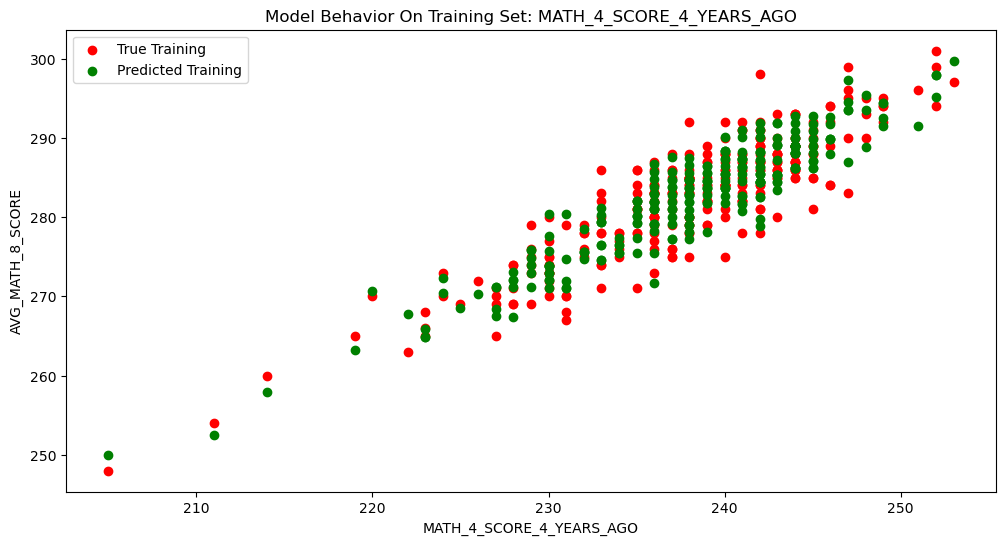

In [71]:
# @@@ 13

predictor_columns = ['PRIOR_MATH_8_SCORE', 'MATH_4_SCORE_4_YEARS_AGO']

for col_name in predictor_columns:
    f = plt.figure(figsize=(12, 6))
    plt.scatter(X_train[col_name], y_train, color="red")
    plt.scatter(X_train[col_name], model.predict(X_train), color="green")

    plt.legend(['True Training', 'Predicted Training'])
    plt.xlabel(col_name)
    plt.ylabel('AVG_MATH_8_SCORE')
    plt.title(f"Model Behavior On Training Set: {col_name}")
    plt.show()

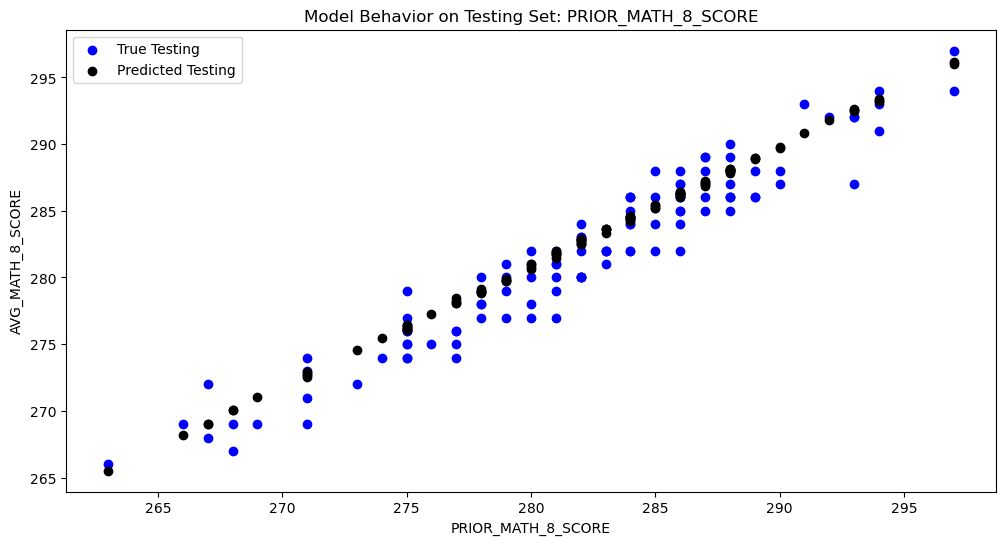

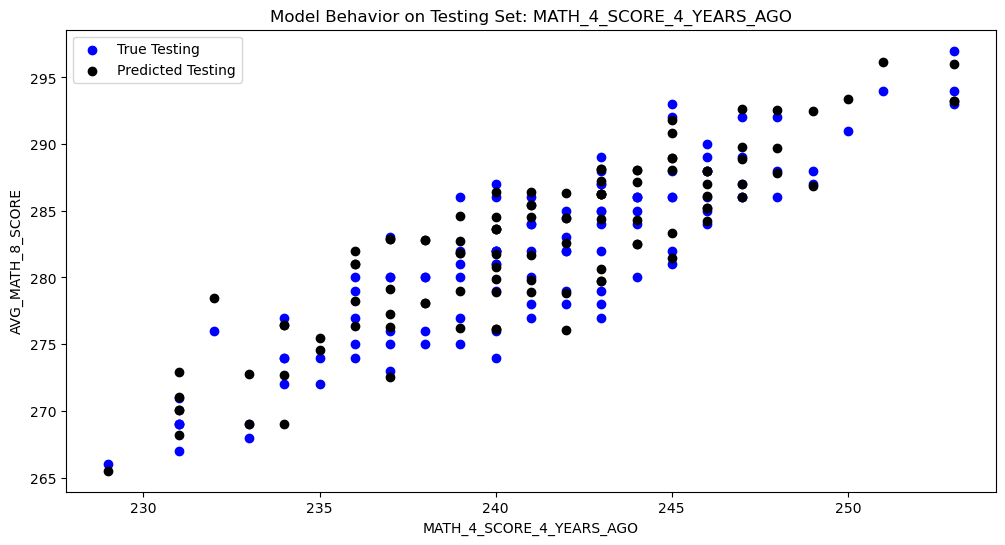

In [70]:
# @@@ 14

predictor_columns = ['PRIOR_MATH_8_SCORE', 'MATH_4_SCORE_4_YEARS_AGO']

for col_name in predictor_columns:
    f = plt.figure(figsize=(12, 6))
    plt.scatter(X_test[col_name], y_test, color="blue")
    plt.scatter(X_test[col_name], model.predict(X_test), color="black")

    plt.legend(['True Testing', 'Predicted Testing'])
    plt.xlabel(col_name)
    plt.ylabel('AVG_MATH_8_SCORE')
    plt.title(f"Model Behavior on Testing Set: {col_name}")
    plt.show()

In [ ]:
# @@@ 15

#using ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

ridge_y_pred = ridge_model.predict(X_test)

ridge_mse = mean_squared_error(y_test, ridge_y_pred)
ridge_r2 = r2_score(y_test, ridge_y_pred)

print("Ridge Mean Squared Error:", ridge_mse)
print("Ridge R^2 Score:", ridge_r2)

Ridge Mean Squared Error: 4.106990476178845
Ridge R^2 Score: 0.9052932562953014


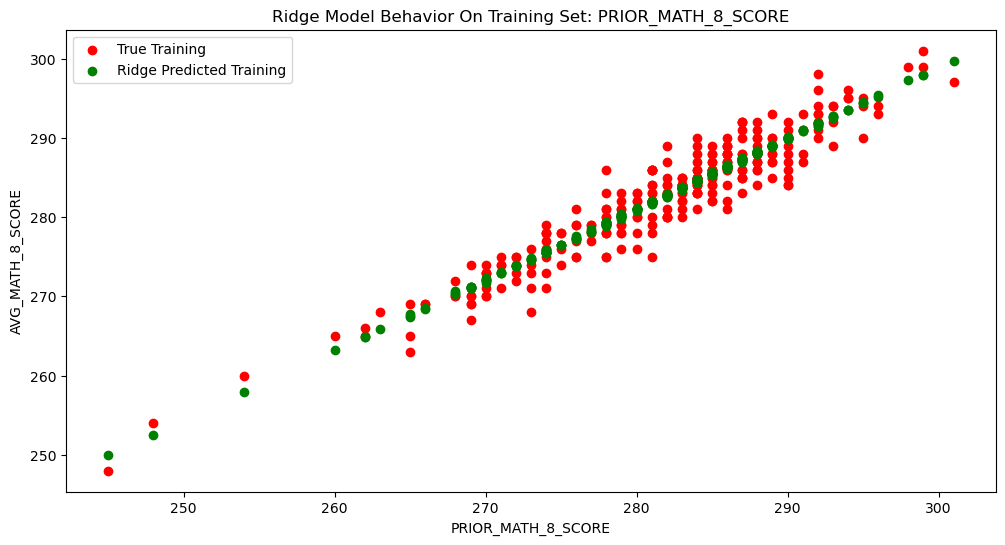

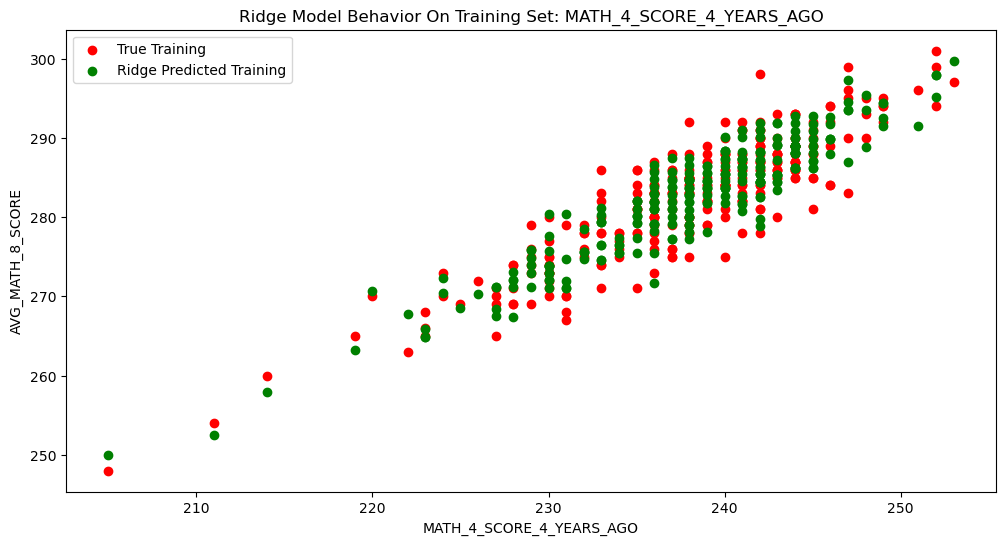

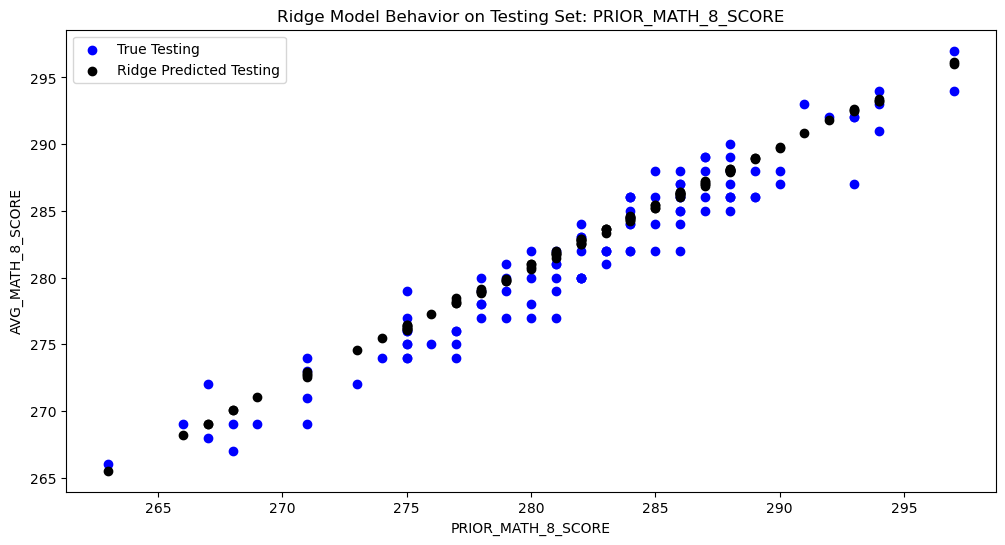

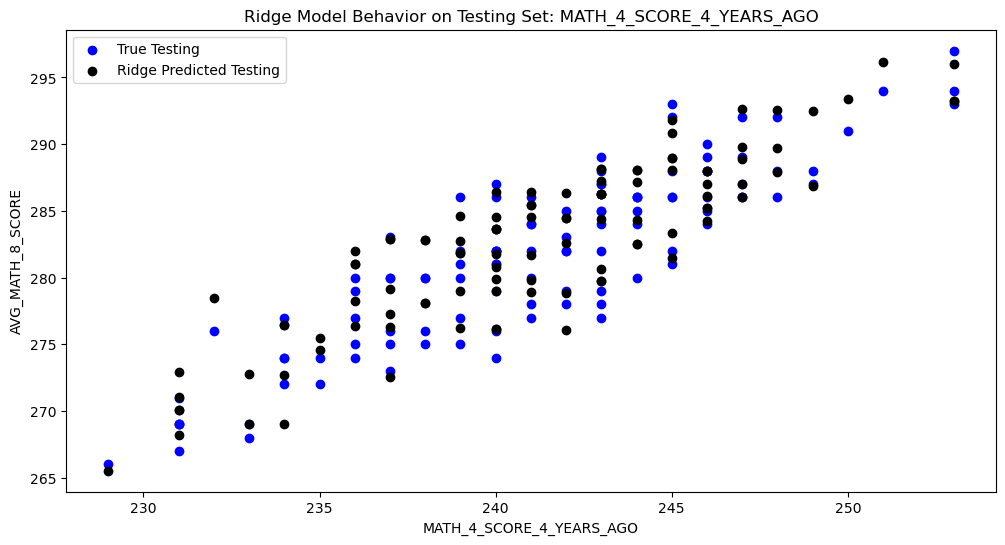

In [75]:
# @@@ 16
# Ridge graphs

predictor_columns = ['PRIOR_MATH_8_SCORE', 'MATH_4_SCORE_4_YEARS_AGO']

for col_name in predictor_columns:
    f = plt.figure(figsize=(12, 6))
    plt.scatter(X_train[col_name], y_train, color="red")
    plt.scatter(X_train[col_name], ridge_model.predict(X_train), color="green")

    plt.legend(['True Training', 'Ridge Predicted Training'])
    plt.xlabel(col_name)
    plt.ylabel('AVG_MATH_8_SCORE')
    plt.title(f"Ridge Model Behavior On Training Set: {col_name}")
    plt.show()

for col_name in predictor_columns:
    f = plt.figure(figsize=(12, 6))
    plt.scatter(X_test[col_name], y_test, color="blue")
    plt.scatter(X_test[col_name], ridge_model.predict(X_test), color="black")

    plt.legend(['True Testing', 'Ridge Predicted Testing'])
    plt.xlabel(col_name)
    plt.ylabel('AVG_MATH_8_SCORE')
    plt.title(f"Ridge Model Behavior on Testing Set: {col_name}")
    plt.show()

Did a little experimentation using ridge. Sometimes less is more, and just linear regression is a bit better.